# Cálculo Científico (I-2026): Taller I: Compresión de Imágenes mediante SVD
**Integrantes:** Amanda Mercedes 31708119
                 Sergio Gómez 30142272

## Parte I: Implementación Computacional
1. Cargue una imagen de alta resolución y conviértala a una matriz de intensidades de gris

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

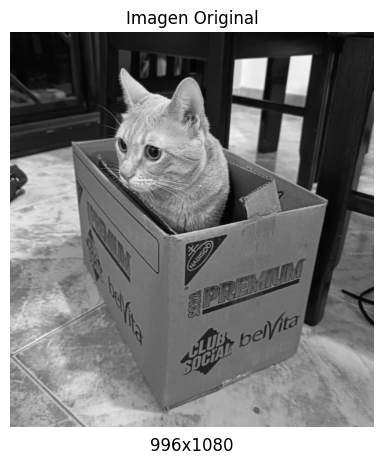

In [2]:
img = Image.open('Kirby.jpeg')
img_gray = img.convert('L')
img_mat = np.array(img_gray)
img_mat = img_mat.astype(float)
ancho, alto = img.size

fig, ax = plt.subplots()
ax.imshow(img_mat, cmap='gray')
ax.set_title("Imagen Original")
fig.suptitle(f"{ancho}x{alto}", y=0.01)

ax.axis('off')

plt.tight_layout()
plt.show()

2. Calcule la SVD de la matriz resultante

In [3]:
u, s, vt = np.linalg.svd(img_mat)

3. Construya aproximaciones $A_k$ para valores de $k \in {5, 20, 50, 100, 200}$.

In [4]:
k_vals = [5, 20, 50, 100, 200]
a_k_mats = []

for k in k_vals:
    a_k = u[:, :k] * s[:k] @ vt[:k, :]
    a_k_mats.append(a_k)

4. Visualice las reconstrucciones y compare visualmente la calidad respecto al original.

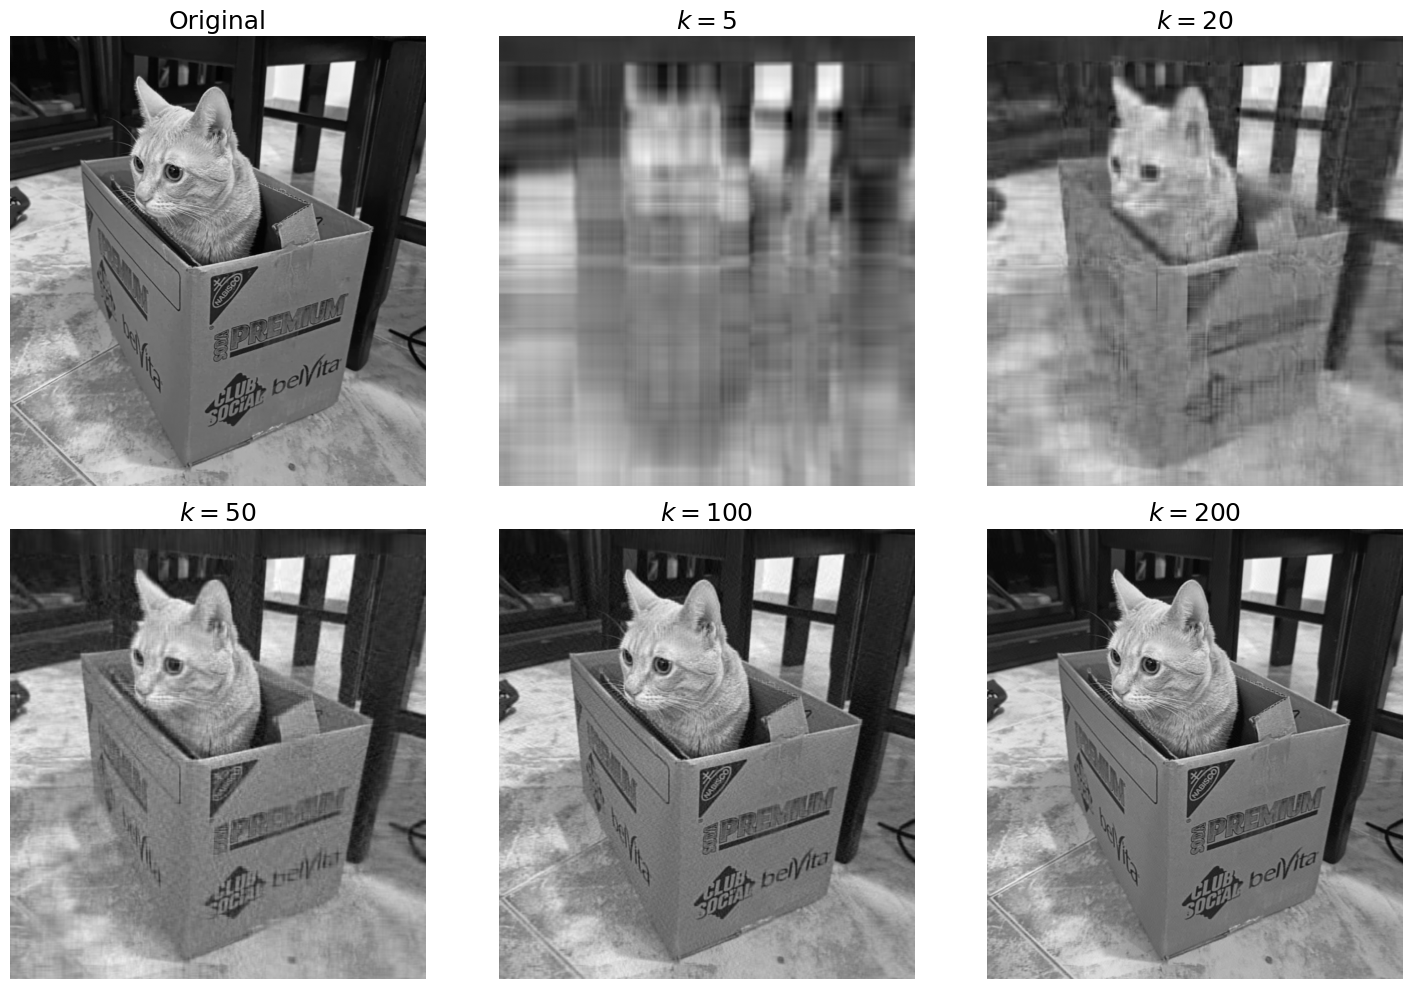

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

ax_f = axes.flatten()

ax_f[0].imshow(img_mat, cmap='gray')
ax_f[0].set_title("Original", fontsize=18)
ax_f[0].axis('off')

for i, k in enumerate(k_vals):
    A_k = a_k_mats[i]
    
    ax_f[i+1].imshow(A_k, cmap='gray')
    ax_f[i+1].set_title(f"$k = {k}$", fontsize=18)
    ax_f[i+1].axis('off')

plt.tight_layout()
fig.savefig("comp.pdf", bbox_inches='tight')
plt.show()

## Parte II: Análisis Cuantitativo
1. **Tasa de Compresión**: Calcule la relación de almacenamiento entre la matriz original ($m\times n$) y los datos necesarios para $A_k$, dados por $k(m + n + 1)$.

In [6]:
tasas_compresion = {}
for k in k_vals:
    tasa = (ancho * alto) / (k * (ancho + alto + 1))
    tasas_compresion[k] = tasa

print(tasas_compresion)

{5: 103.58016369764083, 20: 25.895040924410207, 50: 10.358016369764083, 100: 5.179008184882042, 200: 2.589504092441021}


2. **Análisis de Error**: Grafique el error relativo $\|A − A_k \|F / \|A\|F$ frente al número de valores
singulares utilizados ($k$).

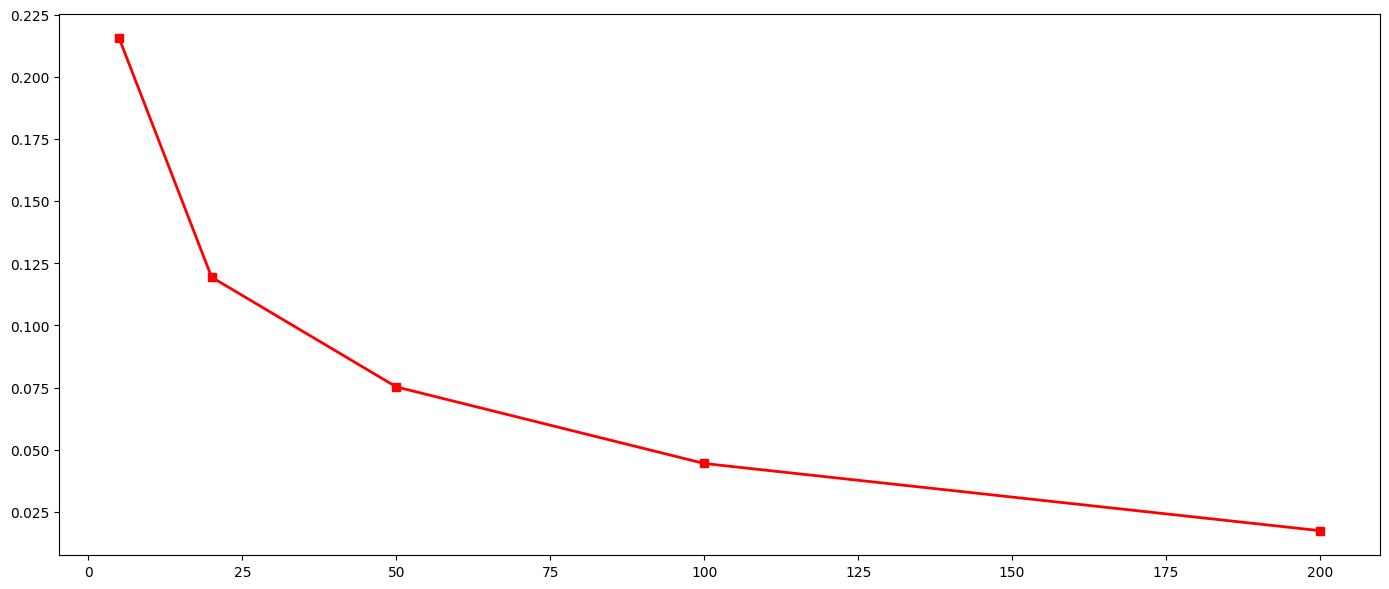

In [11]:
s_cuadrado = s ** 2

a_frob = np.sqrt(np.sum(s_cuadrado))

e_rel = []

for k in k_vals:
    e_abs = np.sqrt(np.sum(s_cuadrado[k:]))
    e_rel.append(e_abs / a_frob)


fig, ax = plt.subplots(1, 1, figsize=(14, 6))

ax.plot(k_vals, e_rel, color='red', marker='s', linestyle='-', linewidth=2)

plt.tight_layout()

plt.show()


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

e_rel_test = []

for k in range(1, min(ancho, alto) + 1):
    e_abs = np.sqrt(np.sum(s_cuadrado[k:]))
    e_rel_test.append(e_abs / a_frob)

ax.plot(range(1, min(ancho, alto) + 1), e_rel_test, color='red', marker='s', linestyle='-', linewidth=2)

plt.show()


3. **Energı́a**: Grafique el porcentaje de la “energı́a” (varianza) capturada, definida como:

$$E(k)= \frac{\sum^k_{i=1} \sigma_i^2}{\sum^r_{i=1} \sigma_i^2}$$

In [ ]:
def energia():
    pass